# Telco Customer Churn Analysis
* Tools: Python (pandas, seaborn, matplotlib), SQL (SQLite)

## 1. Load and Read Data
* Take a first look of data, including data types, basic info, missing values, samples and fix nulls if necessary
* Add Churn_Binary to turn Yes/No into 1/0 so to make it easier when calculating churn rates

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [16]:
# input data and get basic shape
data_path="/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv"
telco=pd.read_csv(data_path)
print("Rows:",telco.shape[0])
print("Columns:",telco.shape[1])

Rows: 7043
Columns: 21


In [19]:
# data types and column names
telco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [21]:
# first 5 rows
telco.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [24]:
# check missing values
telco.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [34]:
# fix TotalCharges: it's stored as sting but some rows have " " blank space, pd.to_numeric turns any non-numbers into NaN
telco['TotalCharges']=pd.to_numeric(telco['TotalCharges'], errors='coerce')
telco['TotalCharges']=telco['TotalCharges'].fillna(0) # new customers fill with 0
telco['TotalCharges'].isnull().sum()

np.int64(0)

In [39]:
# add a numeric churn column (1 = churned, 0 = stayed) to calculate churn rates easier
telco['Churn_Binary'] = (telco['Churn'] == 'Yes').astype(int)

# overall churn rate
overall_churn = telco['Churn_Binary'].mean() * 100
print(f"\nOverall churn rate: {overall_churn:.1f}%")
print(f"Churned: {telco['Churn_Binary'].sum():,} out of {len(telco):,} customers")


Overall churn rate: 26.5%
Churned: 1,869 out of 7,043 customers


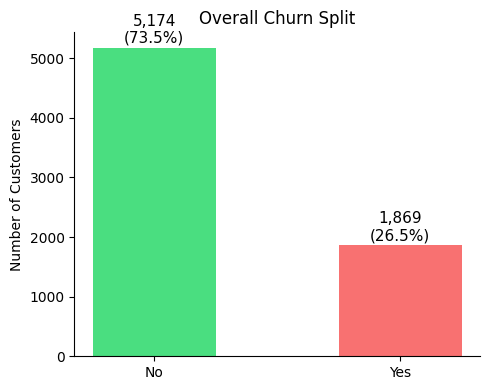

In [40]:
# overall churn split/distribution
fig, ax = plt.subplots(figsize=(5, 4))
counts = telco['Churn'].value_counts()
colors = ['#4ade80', '#f87171']
bars = ax.bar(counts.index, counts.values, color=colors, width=0.5, edgecolor='none')
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f"{val:,}\n({val/len(telco)*100:.1f}%)",
            ha='center', va='bottom', fontsize=11)
ax.set_title("Overall Churn Split")
ax.set_ylabel("Number of Customers")
sns.despine()
plt.tight_layout()
plt.show()

> #### Finding:
> 26.5% of customers churned which is the baseline to explain

## 2. Churn by Categorical Features
* Specifically by Contract, Payment Method, Internet Service

In [ ]:
# calculate churn rate per group and return a sorted DataFrame, to reuse this for every categorical variable
# groupby the column, then take the mean of Churn_Binary
# mean of 0/1 column = proportion = churn rate
def churn_rate_by(col):
    return (
        telco.groupby(col)['Churn_Binary']
        .mean()
        .mul(100)          # convert to percentage
        .round(1)
        .reset_index()
        .rename(columns={'Churn_Binary': 'Churn_Rate_%'})
        .sort_values('Churn_Rate_%', ascending=False)
    )

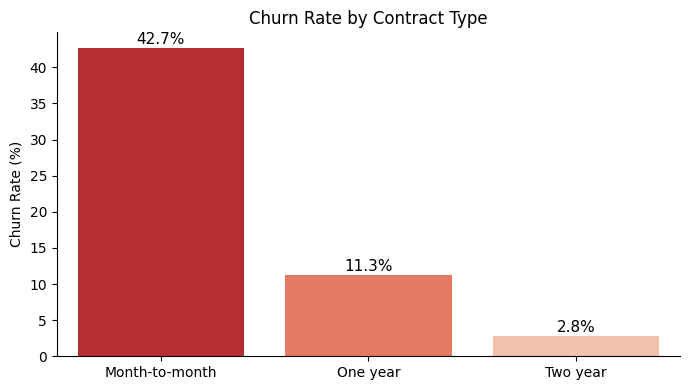

In [43]:
'''2.1 Churn by Contract Type'''
contract_churn = churn_rate_by('Contract')

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=contract_churn, x='Contract', y='Churn_Rate_%',
            palette='Reds_r', ax=ax)
ax.set_title("Churn Rate by Contract Type")
ax.set_ylabel("Churn Rate (%)")
ax.set_xlabel("")

for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%",
                (p.get_x() + p.get_width()/2, p.get_height() + 0.5),
                ha='center', fontsize=11)
sns.despine()
plt.tight_layout()
plt.show()

> #### Finding:
> Month-to-month contract customers churn at 42.7%, much higher than yearly or two-year contract customers. It can be concluded that contract type is the strongest predictor. 

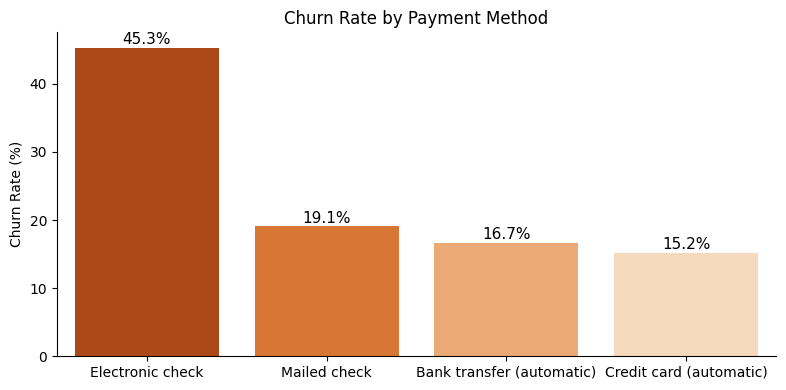

In [47]:
'''2.2 Churn by Payment Method'''
payment_churn = churn_rate_by('PaymentMethod')

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=payment_churn, x='PaymentMethod', y='Churn_Rate_%',
            palette='Oranges_r', ax=ax)
ax.set_title("Churn Rate by Payment Method")
ax.set_ylabel("Churn Rate (%)")
ax.set_xlabel("")

for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%",
                (p.get_x() + p.get_width()/2, p.get_height() + 0.5),
                ha='center', fontsize=11)
sns.despine()
plt.tight_layout()
plt.show()

> #### Finding:
> Electronic check users churn most, which indicates possibly less committed customers.

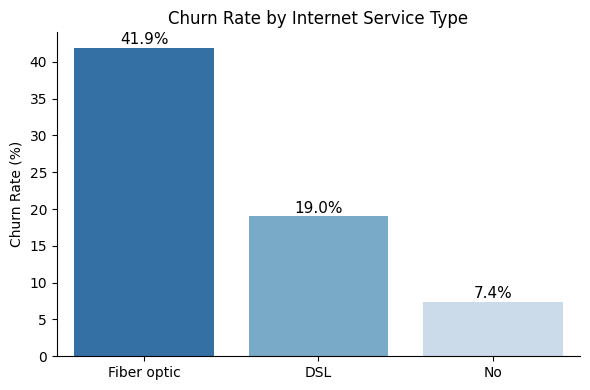

In [49]:
'''2.3 Churn by Internet Service'''
internet_churn = churn_rate_by('InternetService')

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=internet_churn, x='InternetService', y='Churn_Rate_%',
            palette='Blues_r', ax=ax)
ax.set_title("Churn Rate by Internet Service Type")
ax.set_ylabel("Churn Rate (%)")
ax.set_xlabel("")

for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%",
                (p.get_x() + p.get_width()/2, p.get_height() + 0.5),
                ha='center', fontsize=11)
sns.despine()
plt.tight_layout()
plt.show()

> #### Finding:
> Fiber optic customers churn mouchmore than DSL customers, which indicates possible pricing or service quality issue.

## 3. Churn by Numeric Features
* Specifically by Tenure, Monthly Charges

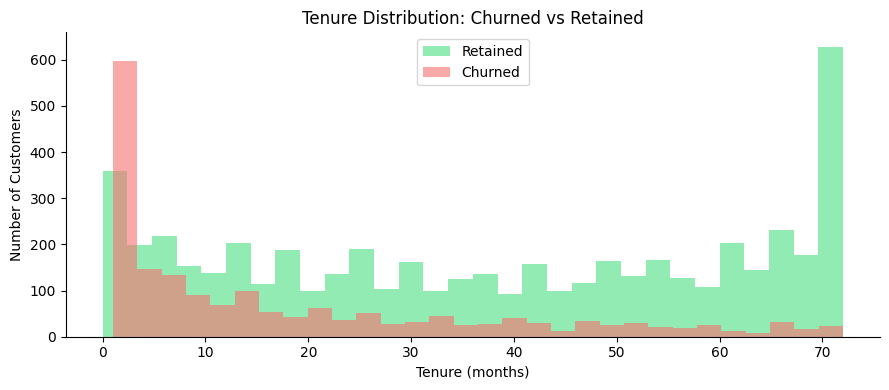

In [52]:
'''3.1 Tenure distribution: churned vs retained'''
fig, ax = plt.subplots(figsize=(9, 4))

telco[telco['Churn'] == 'No']['tenure'].plot(kind='hist', bins=30, alpha=0.6,
                                        color='#4ade80', label='Retained', ax=ax)
telco[telco['Churn'] == 'Yes']['tenure'].plot(kind='hist', bins=30, alpha=0.6,
                                         color='#f87171', label='Churned', ax=ax)

ax.set_title("Tenure Distribution: Churned vs Retained")
ax.set_xlabel("Tenure (months)")
ax.set_ylabel("Number of Customers")
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

> #### Finding:
> Most churned customers have very short tenure (0-12 months), long-term customers are uch less likely to leave.

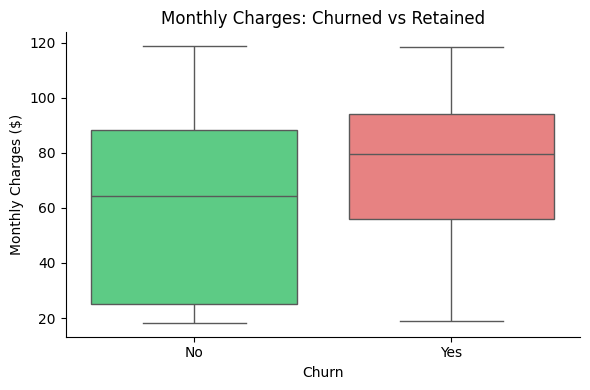

In [53]:
'''3.2 Monthly Charges: boxplot by churn'''
fig, ax = plt.subplots(figsize=(6, 4))

sns.boxplot(data=telco, x='Churn', y='MonthlyCharges',
            palette={'No': '#4ade80', 'Yes': '#f87171'}, ax=ax)
ax.set_title("Monthly Charges: Churned vs Retained")
ax.set_xlabel("Churn")
ax.set_ylabel("Monthly Charges ($)")
sns.despine()
plt.tight_layout()
plt.show()

> #### Finding:
> Churned customers pay significantly higher monthly charges on average. Higher price may drive dissatisfaction among customers.

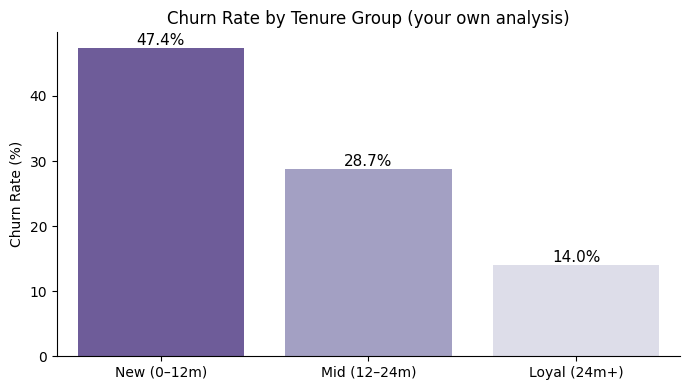

In [54]:
'''3.3 Tenure bucketed into groups'''
# Cut tenure into 3 buckets: new (0-12m), mid (12-24m), loyal (24m+)
telco['Tenure_Group'] = pd.cut(telco['tenure'],
                             bins=[0, 12, 24, 72],
                             labels=['New (0–12m)', 'Mid (12–24m)', 'Loyal (24m+)'],
                             include_lowest=True)

tenure_churn = churn_rate_by('Tenure_Group')

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=tenure_churn, x='Tenure_Group', y='Churn_Rate_%',
            palette='Purples_r', ax=ax)
ax.set_title("Churn Rate by Tenure Group (your own analysis)")
ax.set_ylabel("Churn Rate (%)")
ax.set_xlabel("")
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%",
                (p.get_x() + p.get_width()/2, p.get_height() + 0.5),
                ha='center', fontsize=11)
sns.despine()
plt.tight_layout()
plt.show()

> #### Finding:
> New customers(0-12m) churn at 47.4% which is nearly 3 times higher than loyal customers (24m+), thus early retention is critical.

## 4. SQL Layer

In [55]:
import sqlite3

# Create an in-memory SQLite database and load the dataframe into it
conn = sqlite3.connect(':memory:')
telco.to_sql('telco', conn, index=False, if_exists='replace')

# Helper: run a SQL query and return a DataFrame
def run_sql(query):
    return pd.read_sql_query(query, conn)

'''SQL Query 1: Churn rate by Contract Type'''
q1 = """
SELECT
    Contract,
    COUNT(*) AS total_customers,
    SUM(Churn_Binary) AS churned,
    ROUND(SUM(Churn_Binary) * 100.0 / COUNT(*), 1) AS churn_rate_pct
FROM telco
GROUP BY Contract
ORDER BY churn_rate_pct DESC
"""
print("Query 1 — Churn Rate by Contract Type:")
print(run_sql(q1))

# This should match the bar chart you made in Python on Day 2 — good cross-check!


'''SQL Query 2: Avg monthly charges for churned vs retained'''
q2 = """
SELECT
    Churn,
    ROUND(AVG(MonthlyCharges), 2) AS avg_monthly_charges,
    ROUND(AVG(tenure), 1) AS avg_tenure_months,
    COUNT(*) AS total_customers
FROM telco
GROUP BY Churn
"""
print("\nQuery 2 — Avg Charges & Tenure by Churn Status:")
print(run_sql(q2))


'''SQL Query 3: Top 3 highest-churn customer segments'''
# Combine Contract + InternetService to find the riskiest combinations
q3 = """
SELECT
    Contract,
    InternetService,
    COUNT(*) AS total,
    SUM(Churn_Binary) AS churned,
    ROUND(SUM(Churn_Binary) * 100.0 / COUNT(*), 1) AS churn_rate_pct,
    ROW_NUMBER() OVER (ORDER BY SUM(Churn_Binary) * 100.0 / COUNT(*) DESC) AS rank
FROM telco
GROUP BY Contract, InternetService
HAVING COUNT(*) > 50   -- only include segments with meaningful sample size
ORDER BY churn_rate_pct DESC
LIMIT 3
"""
print("\nQuery 3 — Top 3 Highest-Churn Customer Segments:")
print(run_sql(q3))

conn.close()

Query 1 — Churn Rate by Contract Type:
         Contract  total_customers  churned  churn_rate_pct
0  Month-to-month             3875     1655            42.7
1        One year             1473      166            11.3
2        Two year             1695       48             2.8

Query 2 — Avg Charges & Tenure by Churn Status:
  Churn  avg_monthly_charges  avg_tenure_months  total_customers
0    No                61.27               37.6             5174
1   Yes                74.44               18.0             1869

Query 3 — Top 3 Highest-Churn Customer Segments:
         Contract InternetService  total  churned  churn_rate_pct  rank
0  Month-to-month     Fiber optic   2128     1162            54.6     1
1  Month-to-month             DSL   1223      394            32.2     2
2        One year     Fiber optic    539      104            19.3     3


## 5. Key Findings & Recommendations 

**BUSINESS QUESTION:
Which customers are most at risk of churning, and what should
the business do about it?**

**KEY FINDINGS:**
1. Overall churn rate is ~26.5% — roughly 1 in 4 customers leaves.

2. Contract type is the strongest predictor:
   - Month-to-month: ~43% churn rate
   - One year:       ~11% churn rate
   - Two year:        ~3% churn rate
   
   → Customers without long-term commitment are highly at risk.

3. New customers churn the most:
   - Tenure 0–12 months: ~47% churn rate
   - Tenure 24+ months: ~14% churn rate
   
   → The first year is the most critical retention window.

4. Fiber optic internet customers churn more than DSL (~42% vs ~19%).


   → May indicate a pricing or service quality issue for fiber.

6. Electronic check users have the highest churn among payment methods.


   → Could signal a less engaged or committed customer segment.

**RECOMMENDATIONS:**
1. Prioritise Month-to-month + new customer (0–12m) segment for
   retention campaigns — offer incentives to upgrade to annual contracts.

2. Investigate why Fiber Optic customers churn more — survey this segment
   to understand if it's pricing, reliability, or competition.

3. Set up an early warning system: flag customers with
   month-to-month contract + tenure < 12m + monthly charges > $65
   as high-risk for proactive outreach.